# 05 — Image Compression
## Smart City Surveillance System — CS 406 Digital Image Processing CCP

**Requires:** `01_preprocessing.ipynb` must be run first.

Covers: JPEG-style DCT-based compression at multiple quality levels, Wavelet compression at multiple thresholds, and rate-distortion curves (compression ratio vs PSNR/SSIM) — directly addressing the brief's 'Compression vs. Image Fidelity' trade-off requirement.

## Step 1 — Mount Google Drive, install PyWavelets, set paths

In [ ]:
!pip install PyWavelets -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'
PROCESSED_DIR = Path(f'{PROJECT_DIR}/data/processed')

assert PROCESSED_DIR.exists(), 'Run 01_preprocessing.ipynb first — processed data not found in Drive.'
print('Data found. Ready to proceed.')

Mounted at /content/drive
Data found. Ready to proceed.


## Step 2 — Imports and metrics

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pywt
import os
import random
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_psnr(original, processed):
    return psnr(original, processed, data_range=255)

def compute_ssim(original, processed):
    return ssim(original, processed, channel_axis=-1 if original.ndim == 3 else None, data_range=255)

## Step 3 — Load a test image

In [ ]:
test_img_path = list((PROCESSED_DIR / "with_mask").glob("*.jpg"))[0]
test_img = cv2.imread(str(test_img_path))

original_size_bytes = os.path.getsize(test_img_path)
print(f"Original file size: {original_size_bytes / 1024:.2f} KB")

Original file size: 27.95 KB


## Step 4 — JPEG-style compression at multiple quality levels
OpenCV's JPEG encoder is the real DCT-based JPEG algorithm — we sweep quality levels to show the fidelity/size trade-off, which is exactly what the brief asks for.

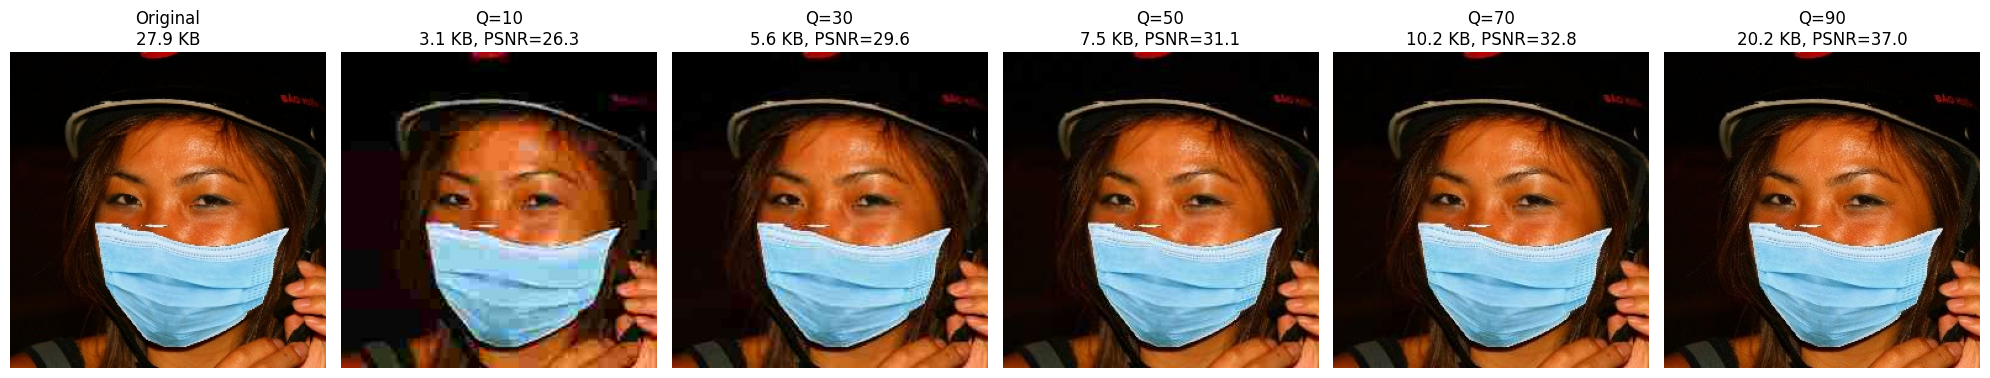

   quality    size_kb  compression_ratio       psnr      ssim
0       10   3.095703           9.027445  26.343447  0.675303
1       30   5.584961           5.003847  29.606697  0.814218
2       50   7.490234           3.731030  31.142675  0.861344
3       70  10.157227           2.751370  32.823556  0.904271
4       90  20.224609           1.381796  36.955208  0.956630


In [ ]:
def jpeg_compress(img, quality):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    success, encoded = cv2.imencode('.jpg', img, encode_param)
    compressed_size = len(encoded)
    decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    return decoded, compressed_size

quality_levels = [10, 30, 50, 70, 90]
jpeg_results = []

fig, axes = plt.subplots(1, len(quality_levels) + 1, figsize=(20, 4))
axes[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original\n{original_size_bytes/1024:.1f} KB")
axes[0].axis("off")

for ax, q in zip(axes[1:], quality_levels):
    decoded, size_bytes = jpeg_compress(test_img, q)
    p = compute_psnr(test_img, decoded)
    s = compute_ssim(test_img, decoded)
    ratio = original_size_bytes / size_bytes
    jpeg_results.append({'quality': q, 'size_kb': size_bytes/1024, 'compression_ratio': ratio, 'psnr': p, 'ssim': s})
    ax.imshow(cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Q={q}\n{size_bytes/1024:.1f} KB, PSNR={p:.1f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/jpeg_compression_comparison.png', dpi=150)
plt.show()

jpeg_df = pd.DataFrame(jpeg_results)
print(jpeg_df)

## Step 5 — Wavelet compression at multiple thresholds
Implements compression via wavelet transform + coefficient thresholding (values below the threshold are zeroed out, then the image is reconstructed) — the core idea behind formats like JPEG2000.

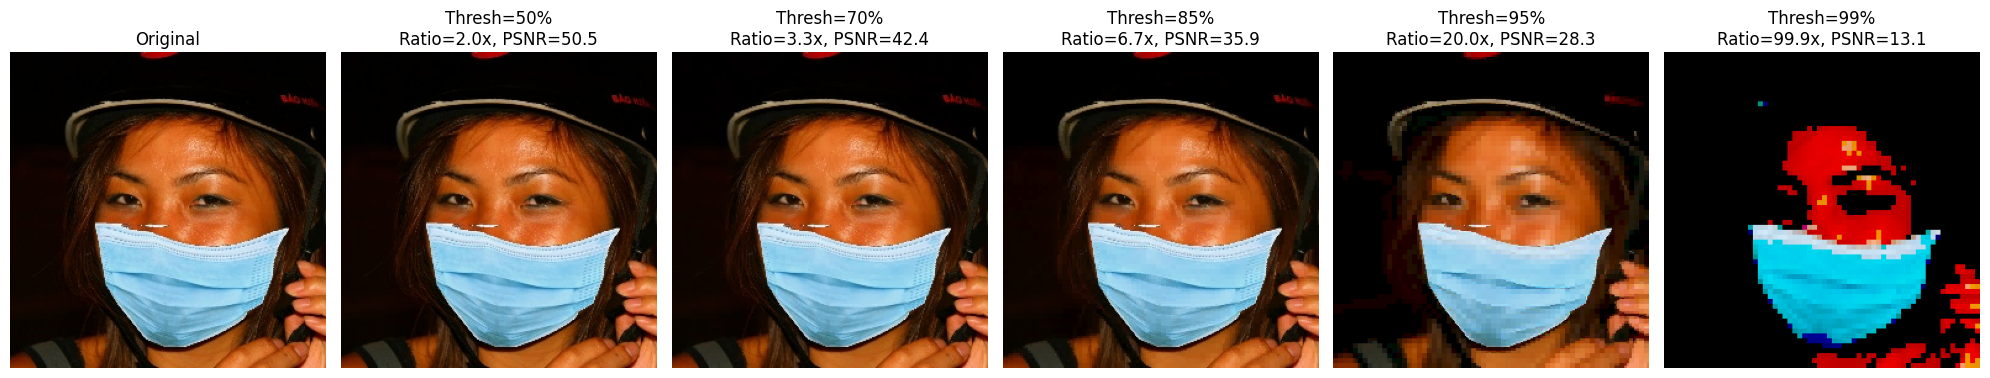

   threshold_pct  sparsity_ratio       psnr      ssim
0             50        1.989174  50.469781  0.992845
1             70        3.327432  42.443510  0.968965
2             85        6.654077  35.907584  0.897569
3             95       19.984550  28.271392  0.681377
4             99       99.851701  13.126531  0.307539


In [ ]:
def wavelet_compress(img, threshold_pct, wavelet='haar'):
    channels = cv2.split(img)
    compressed_channels = []
    total_coeffs = 0
    nonzero_coeffs = 0

    for ch in channels:
        coeffs = pywt.wavedec2(ch.astype(np.float64), wavelet, level=2)
        coeff_arr, coeff_slices = pywt.coeffs_to_array(coeffs)

        threshold_val = np.percentile(np.abs(coeff_arr), threshold_pct)
        coeff_arr_thresh = np.where(np.abs(coeff_arr) < threshold_val, 0, coeff_arr)

        total_coeffs += coeff_arr.size
        nonzero_coeffs += np.count_nonzero(coeff_arr_thresh)

        coeffs_thresh = pywt.array_to_coeffs(coeff_arr_thresh, coeff_slices, output_format='wavedec2')
        reconstructed = pywt.waverec2(coeffs_thresh, wavelet)
        reconstructed = reconstructed[:ch.shape[0], :ch.shape[1]]
        compressed_channels.append(np.clip(reconstructed, 0, 255).astype(np.uint8))

    compressed_img = cv2.merge(compressed_channels)
    sparsity_ratio = total_coeffs / max(nonzero_coeffs, 1)
    return compressed_img, sparsity_ratio

threshold_levels = [50, 70, 85, 95, 99]
wavelet_results = []

fig, axes = plt.subplots(1, len(threshold_levels) + 1, figsize=(20, 4))
axes[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

for ax, t in zip(axes[1:], threshold_levels):
    compressed, ratio = wavelet_compress(test_img, t)
    p = compute_psnr(test_img, compressed)
    s = compute_ssim(test_img, compressed)
    wavelet_results.append({'threshold_pct': t, 'sparsity_ratio': ratio, 'psnr': p, 'ssim': s})
    ax.imshow(cv2.cvtColor(compressed, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Thresh={t}%\nRatio={ratio:.1f}x, PSNR={p:.1f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/wavelet_compression_comparison.png', dpi=150)
plt.show()

wavelet_df = pd.DataFrame(wavelet_results)
print(wavelet_df)

## Step 6 — Rate-Distortion curves: Compression Ratio vs PSNR/SSIM
This is the key plot for the brief's 'Compression vs. Image Fidelity' trade-off requirement — shows exactly how much fidelity you sacrifice for each unit of compression, for both methods.

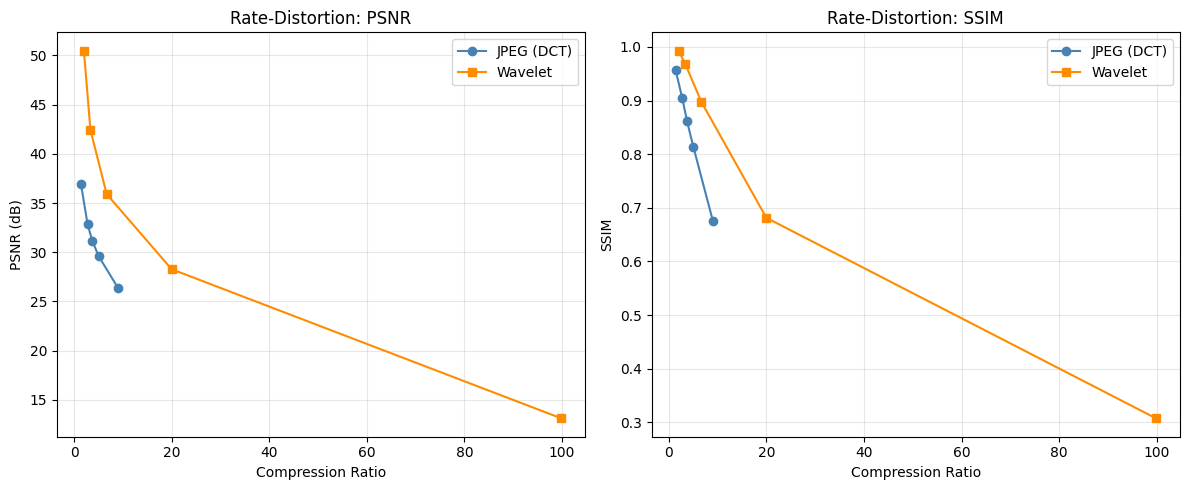

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(jpeg_df['compression_ratio'], jpeg_df['psnr'], 'o-', label='JPEG (DCT)', color='steelblue')
axes[0].plot(wavelet_df['sparsity_ratio'], wavelet_df['psnr'], 's-', label='Wavelet', color='darkorange')
axes[0].set_xlabel("Compression Ratio")
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("Rate-Distortion: PSNR")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(jpeg_df['compression_ratio'], jpeg_df['ssim'], 'o-', label='JPEG (DCT)', color='steelblue')
axes[1].plot(wavelet_df['sparsity_ratio'], wavelet_df['ssim'], 's-', label='Wavelet', color='darkorange')
axes[1].set_xlabel("Compression Ratio")
axes[1].set_ylabel("SSIM")
axes[1].set_title("Rate-Distortion: SSIM")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/rate_distortion_curves.png', dpi=150)
plt.show()

## Step 7 — Full evaluation across the dataset

In [ ]:
random.seed(42)
results = []
class_names = ["with_mask", "without_mask", "incorrect_mask"]
SAMPLE_SIZE = 20

for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), SAMPLE_SIZE)

    for f in files:
        img = cv2.imread(str(f))
        orig_size = os.path.getsize(f)

        for q in [30, 70, 90]:
            decoded, size_bytes = jpeg_compress(img, q)
            results.append({
                "class": class_name, "method": f"jpeg_q{q}",
                "compression_ratio": orig_size / size_bytes,
                "psnr": compute_psnr(img, decoded), "ssim": compute_ssim(img, decoded)
            })

        for t in [70, 90]:
            compressed, ratio = wavelet_compress(img, t)
            results.append({
                "class": class_name, "method": f"wavelet_t{t}",
                "compression_ratio": ratio,
                "psnr": compute_psnr(img, compressed), "ssim": compute_ssim(img, compressed)
            })

df = pd.DataFrame(results)
df.to_csv(f'{PROJECT_DIR}/results/tables/compression_results.csv', index=False)
summary = df.groupby(["method"])[["compression_ratio", "psnr", "ssim"]].mean().round(3)
summary.to_csv(f'{PROJECT_DIR}/results/tables/compression_summary.csv')
print(summary)

             compression_ratio    psnr   ssim
method                                       
jpeg_q30                 4.608  32.413  0.892
jpeg_q70                 2.574  36.310  0.943
jpeg_q90                 1.328  40.682  0.975
wavelet_t70              3.321  42.814  0.976
wavelet_t90              9.991  33.361  0.883


---
**Phase 6 (Compression) complete.** Results saved to Drive:
- `results/figures/jpeg_compression_comparison.png`
- `results/figures/wavelet_compression_comparison.png`
- `results/figures/rate_distortion_curves.png` — your key figure for this section
- `results/tables/compression_summary.csv`

**Expected finding for your Discussion:** JPEG typically achieves better PSNR at moderate compression ratios (it's a mature, optimized standard), while Wavelet compression tends to preserve structural similarity (SSIM) better at high compression ratios since it avoids JPEG's blocky 8x8 DCT artifacts — a good talking point for the 'Compression vs. Fidelity' trade-off.

**Next: `06_recognition.ipynb`** — the optional object recognition task (YOLO fine-tuning on the Face Mask Dataset) plus the full performance/speed benchmarking that ties all phases together.

In [ ]:
# ===== Per-Class Compression Breakdown + BPP =====
per_class_results = []
random.seed(42)

for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), 20)

    for f in files:
        img = cv2.imread(str(f))
        h, w = img.shape[:2]
        total_pixels = h * w

        decoded, size_bytes = jpeg_compress(img, 70)
        bpp = (size_bytes * 8) / total_pixels
        per_class_results.append({
            "class": class_name, "method": "jpeg_q70",
            "bpp": bpp, "psnr": compute_psnr(img, decoded)
        })

per_class_df = pd.DataFrame(per_class_results)
per_class_summary = per_class_df.groupby("class")[["bpp", "psnr"]].mean().round(3)
per_class_summary.to_csv(f'{PROJECT_DIR}/results/tables/compression_per_class.csv')
print(per_class_summary)

                  bpp    psnr
class                        
incorrect_mask  1.366  33.234
with_mask       1.263  34.722
without_mask    0.869  40.976
